In [3]:
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sou = pd.read_csv('data/SOTU.csv')
sou.head()

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169


## Part 2: Simple Text Processing - Tokenization, Lemmatization, Word Frequency, Vectorization (20 pts)

Now we will start working on simple text processing using the `SpaCy` package and the same dataset as Part 1. The package should already be included in the `environment.yml`. However, we will also need to download `en_core_web_sm`, an English language text processing model. To do this, while having your `sotu` environment activated, run the following:

```
python -m spacy download en_core_web_sm
```

Now, you should be good to go!

Some important definitions:

- *Token*: a single word or piece of a word
- *Lemma*: the core component of a word, e.g., "complete" is the lemma for "completed" and "completely"
- *Stop Word*: a common word that does not add semantic value, such as "a", "and", "the", etc.
- *Vectorization*: representing a document as a vector where each index in the vector corresponds to a token or word and each entry is the count.

In this section, we will explore the most common tokens and lemmas throughout different slices of the speech data. We will also develop vectorization representations of the speeches. 

 The core steps are:

1. Process speeches using the SpaCy nlp module
2. Analyze Tokens vs Lemmas:
- Create a list of all tokens across all speeches that are not stop words, punctuation, or spaces.
- Create a second list of the lemmas for these same tokens.
- Display the top 25 for each of these and compare.
3. Analyze common word distributions over different years:
- Create a function that takes the dataset and a year as an input and outputs the top n lemmas for that year's speeches
- Compare the top 10 words for 2023 versus 2019
4. Document Vectorization:
- Train a Term Frequency-Inverse Document Frequency (TF-IDF) vectorization model using your processed dataset and scikit learn
- Output the feature vectors 

**Helpful Resources:**
- https://realpython.com/natural-language-processing-spacy-python/
- https://www.statology.org/text-preprocessing-feature-engineering-spacy/ 
- https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html# 
- https://www.geeksforgeeks.org/nlp/how-to-store-a-tfidfvectorizer-for-future-use-in-scikit-learn/ 



### Processing Speeches with SpaCy

Lets study just speeches from 2000 and onwards to begin with. So, be sure to subset your DataFrame to just these speeches before continuing!

In [5]:
import spacy
from tqdm import tqdm
from collections import Counter

nlp = spacy.load("en_core_web_sm")

In [6]:
# subset the speech dataframe for speeches from 2000 and onwards
sou2k = sou[sou['Year'] >= 2000]
sou2k['Year'].min(), sou2k['Year'].max()

(2000.0, 2024.0)

In [7]:
# Process each speeches using the 'nlp' function
# Hint - loop through each speech and pass the text into the nlp function above, storing the output in a list
# should take about 30 seconds to process

# fake_docs = [nlp(doc) for doc in tqdm(fake["text"].sample(500, random_state=233857))] 
# real_docs =  [nlp(doc) for doc in tqdm(real["text"].sample(500, random_state=233857))] 
processed_speeches = [nlp(doc) for doc in tqdm(sou2k['Text'])]

100%|██████████| 25/25 [00:25<00:00,  1.02s/it]


### Analyze Tokens vs Lemmas

#### Token List

Create a list of tokens across all speeches that are not spaces, stopwords, or punctuation. Make each token lowercase as well. *Hint: each element of the list we just created are themselves lists of tokens. Token objects have attributes `is_stop`, `is_punct`, and `is_space`.*

In [8]:
tokens = []
for doc in processed_speeches:
    for token in doc:
        if not (token.is_stop or token.is_punct or token.is_space):
            tokenl = token.lower_
            tokens.append(tokenl)

In [9]:
# print top 20 tokens
# Hint - use Counter, and one of the Counter object's methods to display the top 20
cts_tokens = Counter(tokens)
cts_tokens.most_common(20)

[('america', 816),
 ('people', 637),
 ('american', 582),
 ('new', 530),
 ('years', 439),
 ('americans', 437),
 ('world', 425),
 ('year', 406),
 ('country', 369),
 ('jobs', 348),
 ('tonight', 344),
 ('work', 324),
 ('know', 323),
 ('let', 320),
 ('congress', 317),
 ('nation', 311),
 ('time', 301),
 ('help', 282),
 ('need', 266),
 ('tax', 255)]

#### Lemma List

Do the same as above, but for lemmas. *Hint: recall lemmas are components of words. Each token should have an attribute to extract the lemma.*

In [10]:
lemmas = []
for doc in processed_speeches:
    for token in doc:
        if not (token.is_stop or token.is_punct or token.is_space):
            tokenlemma = token.lemma_.lower()
            lemmas.append(tokenlemma)

In [11]:
cts_lemmas = Counter(lemmas)
cts_lemmas.most_common(20)

[('year', 845),
 ('america', 816),
 ('people', 639),
 ('american', 587),
 ('work', 557),
 ('new', 532),
 ('job', 486),
 ('country', 435),
 ('americans', 432),
 ('world', 426),
 ('know', 395),
 ('nation', 388),
 ('help', 378),
 ('need', 353),
 ('time', 351),
 ('tonight', 344),
 ('child', 332),
 ('let', 326),
 ('congress', 317),
 ('come', 301)]

#### Token versus Lemma Comparison

What do you notice about the top tokens versus the top lemmas? 
Consider two tokens - "year" and "years" - how do their counts compare to the lemma "year"?
What about the lemma "child"?

In [12]:
# top 25 for each:
t25_tokens = cts_tokens.most_common(25)
t25_lemmas = cts_lemmas.most_common(25)

***Tokens** are the literal word, while lemmas are the "base" of the word. For example, year and years have the same lemma "year" thus they can get counted together. This allows us to see words that stand on their own meaning in the top 20, and give way to more words to be seen as well, including the lemma "child".*

In [19]:
t25_tbl = pd.DataFrame(
    t25_tokens,
    columns=['token', 'token_freq']
).merge(
    right=pd.DataFrame(t25_lemmas, columns=['lemma', 'lemma_freq']),
    left_index=True, right_index=True
)
t25_tbl

,token,token_freq,lemma,lemma_freq
0,america,816,year,845
1,people,637,america,816
2,american,582,people,639
3,new,530,american,587
4,years,439,work,557
5,americans,437,new,532
6,world,425,job,486
7,year,406,country,435
8,country,369,americans,432
9,jobs,348,world,426


### Common Words

#### Common Words per Year Function

Fill in the below function to obtain the n-most common words in speeches for a given year.

inputs: 
- df raw unprocessed sou dataframe
- year
- n
outputs: 
- top n words for that years

steps:
- subset the dataframe for the year of interest - note the years might not be in int type
- process the subsetted dataframe with spacy
- get the lemmas across all those speeches
- count the top n lemmas

In [25]:
def get_most_common_words(df, year, n=25):
    """
    Processes the SOTU speech for a given year and returns
    the most common non-stopword/punctuation lemmas.
    """

    # Step 1: Subset df
    # Using isclose solves years not being ints
    yoi_df = df[np.isclose(df['Year'], year)]

    # Step 2: Process the text with spaCy
    processed = [nlp(doc) for doc in tqdm(yoi_df['Text'])]

    # Step 3: Get lemmas
    lemmas = []
    for doc in processed:
        for token in doc:
            if not (token.is_stop or token.is_punct or token.is_space):
                tokenlemma = token.lemma_.lower()
                lemmas.append(tokenlemma)

    cts_lemmas = Counter(lemmas)
    return cts_lemmas.most_common(n)

In [27]:
# test it on 2024
get_most_common_words(df=sou, year=2024, n=10)

100%|██████████| 1/1 [00:01<00:00,  1.26s/it]


[('president', 58),
 ('year', 45),
 ('america', 44),
 ('american', 34),
 ('people', 33),
 ('$', 33),
 ('member', 32),
 ('want', 29),
 ('audience', 29),
 ('know', 29)]

#### Compare 2023 to 2017

Run your function from the previous step to get the top 20 words for 2017 and 2023. Plot the words and their frequencies in a barchart and replicate the figure below.

In [28]:
words_2023 = get_most_common_words(df=sou, year=2023, n=20)
words_2017 = get_most_common_words(df=sou, year=2017, n=20)

100%|██████████| 1/1 [00:00<00:00,  1.43it/s]


In [29]:
words_2023

[('year', 58),
 ('go', 56),
 ('let', 45),
 ('know', 40),
 ('people', 39),
 ('job', 38),
 ('america', 36),
 ('come', 33),
 ('law', 33),
 ('pay', 33),
 ('american', 31),
 ('$', 31),
 ('president', 30),
 ('look', 27),
 ('world', 25),
 ('folk', 24),
 ('nation', 24),
 ('audience', 23),
 ('work', 23),
 ('right', 23)]

In [30]:
words_2017

[('american', 34),
 ('america', 29),
 ('country', 26),
 ('nation', 21),
 ('great', 20),
 ('new', 19),
 ('year', 19),
 ('world', 18),
 ('job', 15),
 ('people', 15),
 ('americans', 14),
 ('united', 13),
 ('tonight', 13),
 ('states', 12),
 ('work', 12),
 ('child', 12),
 ('want', 12),
 ('time', 12),
 ('citizen', 11),
 ('right', 11)]

In [35]:
# Hint - put the words and counts into a pd Dataframe for better structure
# and to make plotting easier
df_2017 = pd.DataFrame(words_2017, columns=['Word', 'Count'])
df_2023 = pd.DataFrame(words_2023, columns=['Word', 'Count'])

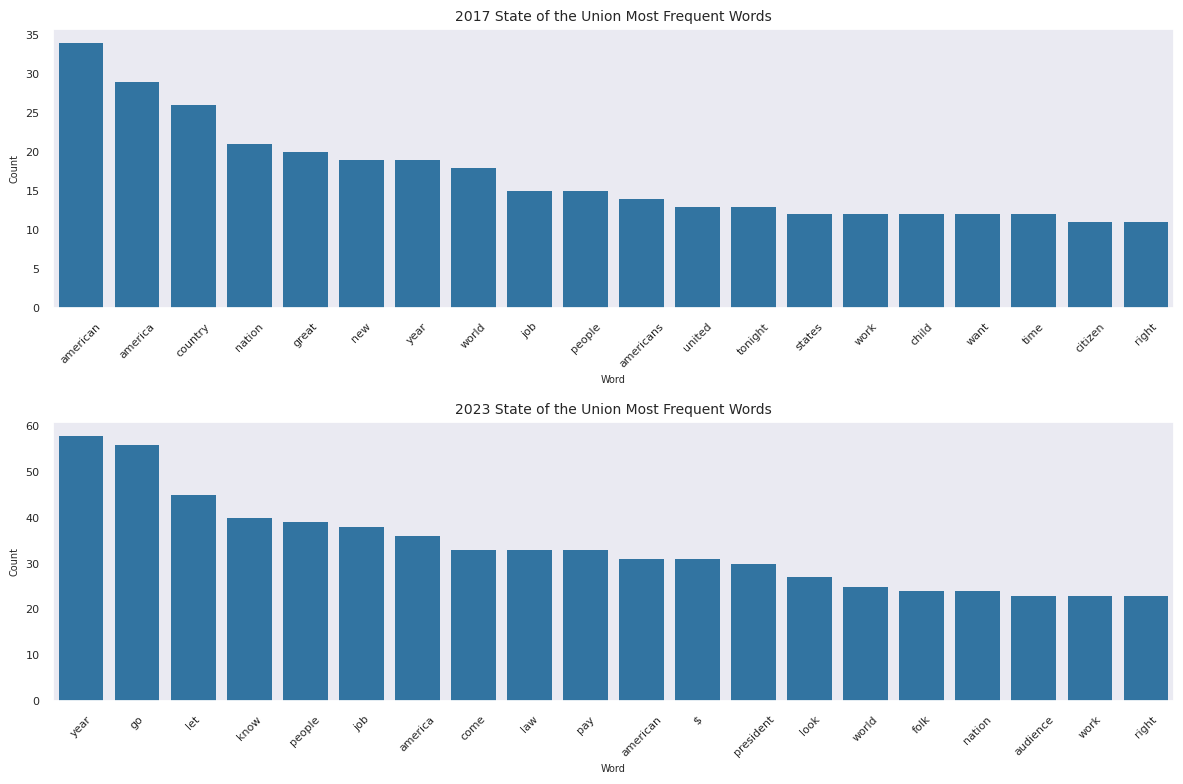

In [91]:
import warnings
warnings.filterwarnings('ignore')
# Hint - use seaborn, subplots, and rotate tick labels
sns.set_theme(style="dark")

fig, ax = plt.subplots(nrows=2, figsize=(12, 8))
sns.barplot(
    data=df_2017, x='Word', y='Count', ax=ax[0],
    linewidth=0, color='#1f77b4'
)
sns.barplot(
    data=df_2023, x='Word', y='Count',
    ax=ax[1], linewidth=0, color='#1f77b4'
)
ax[0].set_title("2017 State of the Union Most Frequent Words", fontsize=10)
ax[1].set_title("2023 State of the Union Most Frequent Words", fontsize=10)

ax[0].set_ylabel("Count", fontsize=7)
ax[1].set_ylabel("Count", fontsize=7)

ax[0].set_xlabel("Word", fontsize=7)
ax[1].set_xlabel("Word", fontsize=7)

ax[0].set_xticklabels(df_2017['Word'], rotation=45, fontsize=8)
ax[1].set_xticklabels(df_2023['Word'], rotation=45, fontsize=8)

ax[0].tick_params(axis='y', labelsize=8)
ax[1].tick_params(axis='y', labelsize=8)
plt.tight_layout();

### TF-IDF Vectorization

To use statsitical alorithms on documents, we need to transform them into vectors, where each element of the vector corresponds to a particular word in a document or corpus of documents. One common way is via TF-IDF embeddings. LLMs work similarly - they typically use transformer models to generate text embeddings before sending text through a deep neural network. 

Here we will fit a TF-IDF vectorizer, plot all the speeches on a 2-D grid using PCA and also using a heatmap, and examine TF-IDF scores for the top 10 most common words in the first speech. This is a good resource here: https://medium.com/GeoffreyGordonAshbrook/vector-visualization-2d-plot-your-tf-idf-with-pca-83fa9fccb1d 

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

#### Train the Vectorizer and Transform the Data

In [93]:
# you may use this as input to fit the TF-IDF vectorizer
raw_docs = sou["Text"].to_list()

In [107]:
# Hint - use fit_transform for vectorizer and PCA
tfidf_model = TfidfVectorizer()
latent_vectors = tfidf_model.fit_transform(raw_documents=raw_docs)

The output of `fit_transform()` will be a matrix where each row corresponds to a speech, each column corresponds to a word in the corpus of speeches, and the value is the TF-IDF score which measures the importance of that word in that speech, relative to the rest of the speeches.

#### Plot Speeches

- First used PCA to generate the first chart
- Second use seaborn heatmap with a log-scaled color axis to generate the second chart

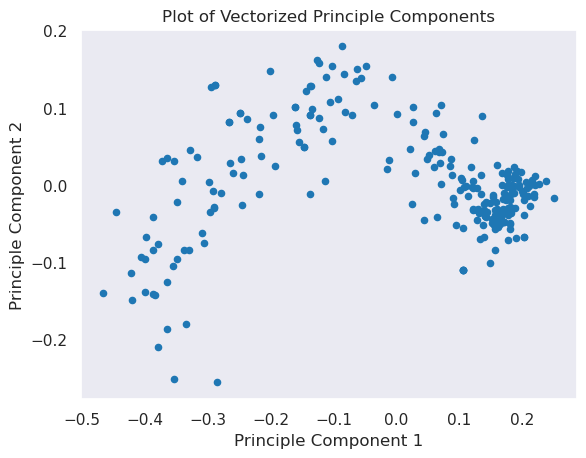

In [119]:
# Step 1: Set PCA to find first 2 principal components
pca = PCA(n_components = 2)
pc12_vec = pca.fit_transform(latent_vectors)

# Step 2: Create a new dataframe where each row is a speech, and each column is a projection onto
# one of the two principal components
pc12_df = pd.DataFrame(pc12_vec, columns=['PC1', 'PC2'])

# Plot Data Visualization (Matplotlib)
pc12_df.plot(
    kind='scatter', x='PC1', y='PC2',
    color='#1f77b4'
)
plt.title('Plot of Vectorized Principle Components')
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2');

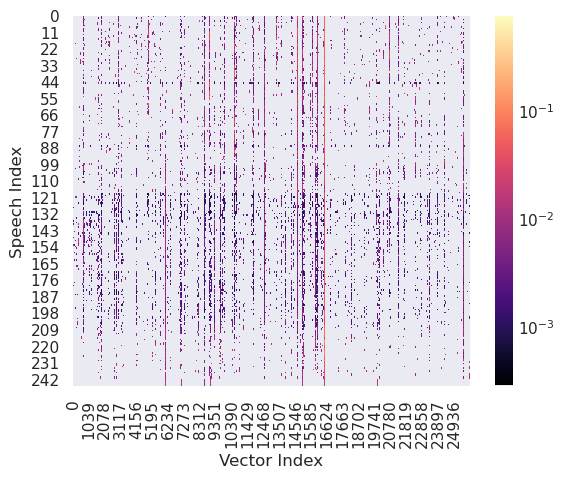

In [141]:
# Hint - vectorized_docs is a sparse matrix whose rows are speeches and columns are tokens, with each
# value being a TF-IDF score. Densify this array first, and then plot using seaborn.
from matplotlib.colors import LogNorm
vectorized_docs = latent_vectors.toarray()
hm = sns.heatmap(
    vectorized_docs,
    norm=LogNorm(),
    cmap='magma'
)

plt.xlabel('Vector Index')
plt.ylabel('Speech Index')

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(which='both', length=0);

#### Get the TF-IDF value for certain words and documents

In [142]:
word_list = ['year',
 'america',
 'people',
 'american',
 'work',
 'new',
 'job',
 'country',
 'americans',
 'world'] # top ten most common words through whole corpus

In [157]:
# get each word's index number using the .vocabular_ attributed of vectorizer
word_nums = [tfidf_model.vocabulary_[wrd] for wrd in word_list]
word_nums

[25879, 2410, 17259, 2412, 25728, 15972, 13576, 6506, 2416, 25753]

In [167]:
# get their IDF score by using .idf_ at the indices from the previous step
idf_score = [tfidf_model.idf_[idx] for idx in word_nums]

In [168]:
# get the tf_idf score for the first speech
tf_idf = vectorized_docs[0, word_nums]

In [170]:
pd.DataFrame({"Word": word_list, "IDF Score": idf_score, "TF-IDF Score": tf_idf})

,Word,IDF Score,TF-IDF Score
0,year,1.032925,0.022719
1,america,1.272946,0.068439
2,people,1.037118,0.043087
3,american,1.102217,0.045792
4,work,1.162281,0.005681
5,new,1.024591,0.016275
6,job,2.043480,0.009988
7,country,1.008130,0.013550
8,americans,1.713598,0.041877
9,world,1.138750,0.026438
